# Question-answering multiple choice questions

Firts, let's download a public MMLU [dataset](https://huggingface.co/datasets/cais/mmlu) from HuggingFace:

In [2]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from config import set_environment

# for the keys - as explained early in chapter 2
set_environment()

In [3]:
from datasets import load_dataset
ds = load_dataset("cais/mmlu", "high_school_geography")

We can explore the dataset:

In [4]:
ds_dict = ds["test"].take(100).to_dict()
print(ds_dict["question"][0])

The main factor preventing subsistence economies from advancing economically is the lack of


In [5]:
print(ds_dict["choices"][0])

['a currency.', 'a well-connected transportation infrastructure.', 'government activity.', 'a banking service.']


In [6]:
ds_dict["choices"][0][ds_dict["answer"][0]]

'a well-connected transportation infrastructure.'

Now, let's create our research agent (pay attention to how we put together the system prompt by describing the agent's profile!):

In [7]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm_small = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=1.0)

In [8]:
from langchain_community.agent_toolkits.load_tools import load_tools
from langgraph.prebuilt import create_react_agent

research_tools = load_tools(
    tool_names=["ddg-search", "arxiv", "wikipedia"],
    llm=llm_small
)

system_prompt = (
    "You're a hard-working, curious and creative student. "
    "You're working on exam question. Think step by step."
    "Always provide an argumentation for you answer. "
    "Do not assume anything, use available tools to search "
    "for evidence and supporting statements."
)


In [9]:
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langgraph.graph import MessagesState
from langgraph.prebuilt.chat_agent_executor import AgentState

raw_prompt_template = (
    "Answer the following multiple-choice question. "
    "\nQUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n"
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("user", raw_prompt_template),
        ("placeholder", "{messages}")
    ]
)

class ResearchState(AgentState):
    question: str
    options: str

research_agent = create_react_agent(model=llm_small, tools=research_tools, state_schema=ResearchState, prompt=prompt)

Now we define another agent that reflects on the anwer and provides critique:

In [10]:
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate

raw_prompt_template_with_critique = (
    "You tried to answer the exam question and you get feedback from you "
    "professor. Work on improving you answer and incorporating the feedback. "
    "\nQUESTION:\n{question}\n\nANSWER OPTIONS:\n{options}\n\n"
    "INITIAL ANSWER:\n{answer}\n\nFEEDBACK:\n{feedback}"
)

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        ("user", raw_prompt_template_with_critique),
        ("placeholder", "{messages}")
    ]
)

class ReflectionState(ResearchState):
    answer: str
    feedback: str

research_agent_with_critique = create_react_agent(
    model=llm_small,
    tools=research_tools,
    state_schema=ReflectionState,
    prompt=prompt
)

In [11]:
from pydantic import BaseModel, Field
from typing import Optional

reflection_prompt = (
    "You are a university professor and you're supervising a student who is "
    "working on multiple-choice exam question. "
    "\nQUESTION: {question}.\nANSWER OPTIONS:\n{options}\n."
    "STUDENT'S ANSWER:\n{answer}\n"
    "Reflect on the answer and provide a feedback whether the answer "
    "is right or wrong. If you think the final answer is correct, reply with "
    "the final answer. Only provide critique if you think the answer might "
    "be incorrect or there are reasoning flaws. Do not assume anything, "
    "evaluate only the reasoning the student provided and whether there is "
    "enough evidence for their answer."
)

class Response(BaseModel):
    """A final response to the user."""

    answer: Optional[str] = Field(
        description="The final answer. It should be empty if critique has been provided.",
        default=None,
    )
    critique: Optional[str] = Field(
        description="A critique of the initial answer. If you think it might be incorrect, provide an actionable feedback",
        default=None,
    )

Let's put everything together and create a multi-agent system:

In [12]:
from typing import Annotated, Literal, TypedDict
from langchain_core.runnables.config import RunnableConfig
from operator import add
from langgraph.graph import StateGraph, START, END


class ReflectionAgentState(TypedDict):
    question: str
    options: str
    answer: str
    steps: Annotated[int, add]
    response: Response


def _should_end(state: ReflectionAgentState, config: RunnableConfig) -> Literal["research", END]:
    max_reasoning_steps = config["configurable"].get("max_reasoning_steps", 10)
    if state.get("response") and state["response"].answer:
        return END
    if state.get("steps", 1) > max_reasoning_steps:
        return END
    return "research"

reflection_chain = PromptTemplate.from_template(reflection_prompt) | llm_small.with_structured_output(Response)

def _reflection_step(state):
    result = reflection_chain.invoke(state)
    return {"response": result, "steps": 1}

def _research_start(state):
    answer = research_agent.invoke(state)
    return {"answer": answer["messages"][-1].content}

def _research(state):
    agent_state = {
        "answer": state["answer"],
        "question": state["question"],
        "options": state["options"],
        "feedback": state["response"].critique
    }
    answer = research_agent_with_critique.invoke(agent_state)
    return {"answer": answer["messages"][-1].content}

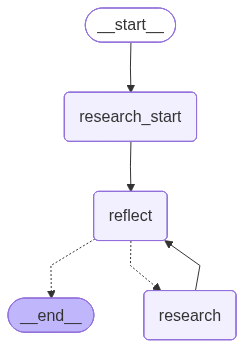

In [15]:
builder = StateGraph(ReflectionAgentState)

builder.add_node("research_start", _research_start)
builder.add_node("research", _research)
builder.add_node("reflect", _reflection_step)

builder.add_edge(START, "research_start")
builder.add_edge("research_start", "reflect")
builder.add_edge("research", "reflect")
builder.add_conditional_edges("reflect", _should_end)
graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

Let's take a random question and run our agent:

In [16]:
i = 3
question = ds_dict["question"][i]
options = "\n".join([f"{i}. {a}" for i, a in enumerate(ds_dict["choices"][i])])

async for _, event in graph.astream({"question": question, "options": options}, stream_mode=["updates"]):
  print(event)

/opt/anaconda3/envs/langchain_ai/lib/python3.10/site-packages/wikipedia/wikipedia.py:389: GuessedAtParserWarning: No parser was explicitly specified, so I'm using the best available HTML parser for this system ("lxml"). This usually isn't a problem, but if you run this code on another system, or in a different virtual environment, it may use a different parser and behave differently.

The code that caused this warning is on line 389 of the file /opt/anaconda3/envs/langchain_ai/lib/python3.10/site-packages/wikipedia/wikipedia.py. To get rid of this warning, pass the additional argument 'features="lxml"' to the BeautifulSoup constructor.

  lis = BeautifulSoup(html).find_all('li')


{'research_start': {'answer': [{'type': 'text', 'text': '*   **Argumentation:**\n    1.  I used the DuckDuckGo search engine to find information about Burgess\'s concentric zone model and the characteristics of its zones.\n    2.  The search results indicated that the model consists of five concentric rings radiating outward from a central business district.\n    3.  Specifically, the search results mentioned: "The theory posits concentric zones round the central area, defined by their residential composition, moving from the very poor and socially deviant, in the inner zone of transition, to a peripheral suburban commuter ring."\n    4.  Another result stated: "The model consists of five concentric rings around a central business district (CBD): the zone of transition, the zone of working-class homes, the zone of middle-class homes, the zone of working-class homes, and the commuter zone."\n    5.  Based on these descriptions, the **Zone of Transition** is identified as the area contai